# Barycenter solver sweep: Sinkhorn vs PDLP vs back-and-forth

Three solvers compute Wasserstein barycenters of the same three icon measures over the
same grid of simplex weights λ, so their outputs are directly comparable:

| solver | formulation | entry point |
|---|---|---|
| **Entropic Sinkhorn** | entropy-regularised, dense cost matrix, log-domain | `uot.solvers.sinkhorn.barycenter.barycenter_sinkhorn` |
| **PDLP** | linear program solved with restarted averaged PDHG | `uot.solvers.pdlp_barycenter.PDLPBarycenterSolver` |
| **Back-and-forth** | unregularised dual ascent on the grid | `uot.solvers.back_and_forth.barycenter.backnforth_barycenter_sqeuclidean_nd_optimized` |

Sinkhorn and PDLP work on the shared union support with an explicit cost matrix; BFM
works directly on the grid.  All three return a field on the same 2D grid, so the
barycenters can be overlaid on the simplex and compared numerically.

This notebook supersedes the earlier `barycenter_icons_barycenter_sweep.ipynb` and
`barycenter_icons_barycenter_sweep_pdlp.ipynb` scratch notebooks.

In [1]:
import sys, os

os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
# Pin the notebook to one accelerator *before* JAX initialises its backend.
# Override from the shell, e.g. CUDA_VISIBLE_DEVICES=1 jupyter nbconvert --execute ...
os.environ.setdefault('CUDA_VISIBLE_DEVICES', '0')
sys.path.insert(0, os.path.abspath(os.path.join('../..')))

from jax import config
config.update('jax_enable_x64', True)

import time
import numpy as np
import pandas as pd
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

from uot.data.dataset_loader import load_image_as_binary_grid
from uot.data.measure import DiscreteMeasure
from uot.problems.barycenter_problem import BarycenterProblem
from uot.utils.costs import cost_euclid_squared
from uot.utils.notebook_helpers import barycenter_inputs
from uot.utils.generate_nd_grid import generate_nd_grid
from uot.solvers.sinkhorn.barycenter import barycenter_sinkhorn
from uot.solvers.pdlp_barycenter import PDLPBarycenterSolver
from uot.solvers.back_and_forth.barycenter import backnforth_barycenter_sqeuclidean_nd_optimized

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 150,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print('devices:', jax.devices())

2026-09-16 01:55:31.350320: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0916 01:55:31.401520  196945 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0916 01:55:31.417883  196945 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


devices: [CudaDevice(id=0)]


## Configuration

The grid size is the binding constraint: Sinkhorn and PDLP both materialise an
(N²×N²) cost matrix over the union support, so 64² already means a 4096×4096 matrix
and three couplings of that size inside PDLP.  Raise `SIZE` only with that in mind.

In [2]:
SIZE = (64, 64)             # image resolution == grid resolution
LAMBDA_STEP = 0.2           # simplex grid spacing; smaller -> more barycenters
IMG_DIR = 'imgs'
SELECTED = ['cristo_redentor.jpg', 'eiffel_tower.jpg', 'pisa_tower.jpg']

SINKHORN_PARAMS = dict(reg=1e-3, tol=1e-4, maxiter=500)
PDLP_PARAMS     = dict(reg=1e-2, tol=1e-4, maxiter=4000)
BFM_PARAMS      = dict(outer_maxiter=10, stopping_tol=1e-3, relaxation=0.9,
                       transport_stepsize=1.0, transport_maxiter=600, transport_tol=1e-3)

In [3]:
measures_raw = [
    load_image_as_binary_grid(
        os.path.join(IMG_DIR, name),
        size=SIZE, threshold=0.2, invert=True,
        normalize=True, axes_mode='normalized',
    )
    for name in SELECTED
]

problem = BarycenterProblem(
    name='icon-barycenter',
    measures=measures_raw,
    cost_fn=cost_euclid_squared,
    lambdas=np.ones(len(measures_raw)) / len(measures_raw),
)

measures, _lambdas, cost, meas_array, support = barycenter_inputs(
    problem, support_mode='shared', shared_mode='union', return_support=True,
)

axes = measures[0].axes
grid_points = np.asarray(generate_nd_grid(axes, use_jax=False))
grid_shape = np.asarray(measures[0].weights_nd).shape

print(f'{len(measures)} measures, grid {grid_shape}, '
      f'support {support.shape[0]} pts, cost matrix {cost.shape}')

3 measures, grid (64, 64), support 4096 pts, cost matrix (4096, 4096)


In [4]:
def aligned_grid_field(points, weights):
    """Place scattered weights on the shared grid and normalise to unit mass."""
    aligned = DiscreteMeasure(points=points, weights=weights).weights_on(
        grid_points, include_zeros=True
    )
    field = np.asarray(aligned).reshape(grid_shape)
    total = field.sum()
    return field / total if total > 0 else field


def normalised_field(array):
    field = np.asarray(array)
    total = field.sum()
    return field / total if total > 0 else field


# The input marginals, on the same grid — used for plots and for the vertex check.
measure_fields = [normalised_field(m.weights_nd) for m in measures]

In [5]:
vals = np.arange(0.0, 1.0 + 1e-9, LAMBDA_STEP)
lambda_grid = []
for l1 in vals:
    for l2 in vals:
        l3 = 1.0 - l1 - l2
        if l3 < -1e-9:
            continue
        lambda_grid.append(np.array([l1, l2, max(l3, 0.0)]))

print(f'{len(lambda_grid)} lambda points on the simplex')

21 lambda points on the simplex


## Solvers

Each solver is wrapped to the same signature — take λ, return a normalised field on
the shared grid plus whatever diagnostics it reports — so the sweep below treats them
interchangeably.

In [6]:
pdlp_solver = PDLPBarycenterSolver()

# PDLP and Sinkhorn consume the union support; BFM consumes the raw grid.
support_marginals = [
    DiscreteMeasure(points=support, weights=meas_array[i], name=f'measure_{i}')
    for i in range(meas_array.shape[0])
]
bfm_measures = jnp.stack([jnp.asarray(f) for f in measure_fields], axis=0)
bfm_coords = [jnp.asarray(ax) for ax in axes]


def run_sinkhorn(lmb):
    b, info = barycenter_sinkhorn(
        measures=meas_array, cost=cost, lambdas=lmb,
        return_diagnostics=True, **SINKHORN_PARAMS,
    )
    diag = dict(iterations=int(np.asarray(info['iterations']).item()),
                error=float(np.asarray(info['error']).item()))
    return aligned_grid_field(support, np.asarray(b)), diag


def run_pdlp(lmb):
    result = pdlp_solver.solve(
        marginals=support_marginals, costs=[cost], weights=lmb, **PDLP_PARAMS,
    )
    b = np.asarray(result['barycenter'])
    # A PDHG primal iterate is only nonnegative in the limit; at finite precision a
    # few entries go slightly below zero.  Clip them, but record how much mass that
    # removed so the violation stays visible instead of being silently absorbed.
    neg_mass = float(-b[b < 0].sum()) if (b < 0).any() else 0.0
    diag = dict(iterations=int(np.asarray(result['iterations']).item()),
                error=float(np.asarray(result['error']).item()),
                neg_mass=neg_mass)
    return aligned_grid_field(support, np.clip(b, 0.0, None)), diag


def run_bfm(lmb):
    b, _ = backnforth_barycenter_sqeuclidean_nd_optimized(
        weights=[float(x) for x in np.asarray(lmb)],
        measures_weights=bfm_measures,
        coordinates=bfm_coords,
        **BFM_PARAMS,
    )
    return normalised_field(b), dict(iterations=np.nan, error=np.nan)


SOLVERS = {
    'sinkhorn': run_sinkhorn,
    'pdlp':     run_pdlp,
    'bfm':      run_bfm,
}

W0916 01:56:14.265705  196945 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.


W0916 01:56:14.611030  196945 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0916 01:56:14.707499  196945 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.


W0916 01:56:14.868118  196945 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0916 01:56:15.022897  196945 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.


W0916 01:56:15.280399  196945 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0916 01:56:15.448400  196945 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.


W0916 01:56:15.602027  196945 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0916 01:56:15.757972  196945 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.


W0916 01:56:16.014768  196945 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0916 01:56:16.102960  196945 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.


## Sweep

Every solver runs on every λ.  The first call of each solver pays JAX compilation, so
the reported time for λ index 0 is compile + solve; later rows are steady state.

In [7]:
fields = {name: [] for name in SOLVERS}
records = []

for name, fn in SOLVERS.items():
    print(f'\n── {name} ──')
    for idx, lmb in enumerate(lambda_grid):
        t0 = time.perf_counter()
        field, diag = fn(lmb)
        jax.block_until_ready(field)
        elapsed = time.perf_counter() - t0

        fields[name].append(field)
        records.append(dict(solver=name, lambda_index=idx,
                            l1=lmb[0], l2=lmb[1], l3=lmb[2],
                            runtime=elapsed, **diag))
        if (idx + 1) % 5 == 0 or idx == 0:
            print(f'  λ=({lmb[0]:.1f},{lmb[1]:.1f},{lmb[2]:.1f})  '
                  f'{idx + 1}/{len(lambda_grid)}  t={elapsed:7.2f}s')

df = pd.DataFrame(records)
print('\nDone. Total rows:', len(df))


── sinkhorn ──


W0916 01:56:16.629675  196945 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.


  λ=(0.0,0.0,1.0)  1/21  t=   5.96s


  λ=(0.0,0.8,0.2)  5/21  t=   1.40s


  λ=(0.2,0.6,0.2)  10/21  t=   0.62s


...

  λ=(0.0,0.8,0.2)  5/21  t= 123.48s


  λ=(0.2,0.6,0.2)  10/21  t= 108.60s


  λ=(0.4,0.6,0.0)  15/21  t= 112.85s


  λ=(0.8,0.2,0.0)  20/21  t= 116.54s



Done. Total rows: 63


## Barycenters over the simplex

Marginals sit at the corners, each barycenter at its weighted position.  A solver that
is behaving puts the original icon back at every corner and interpolates smoothly
between them.

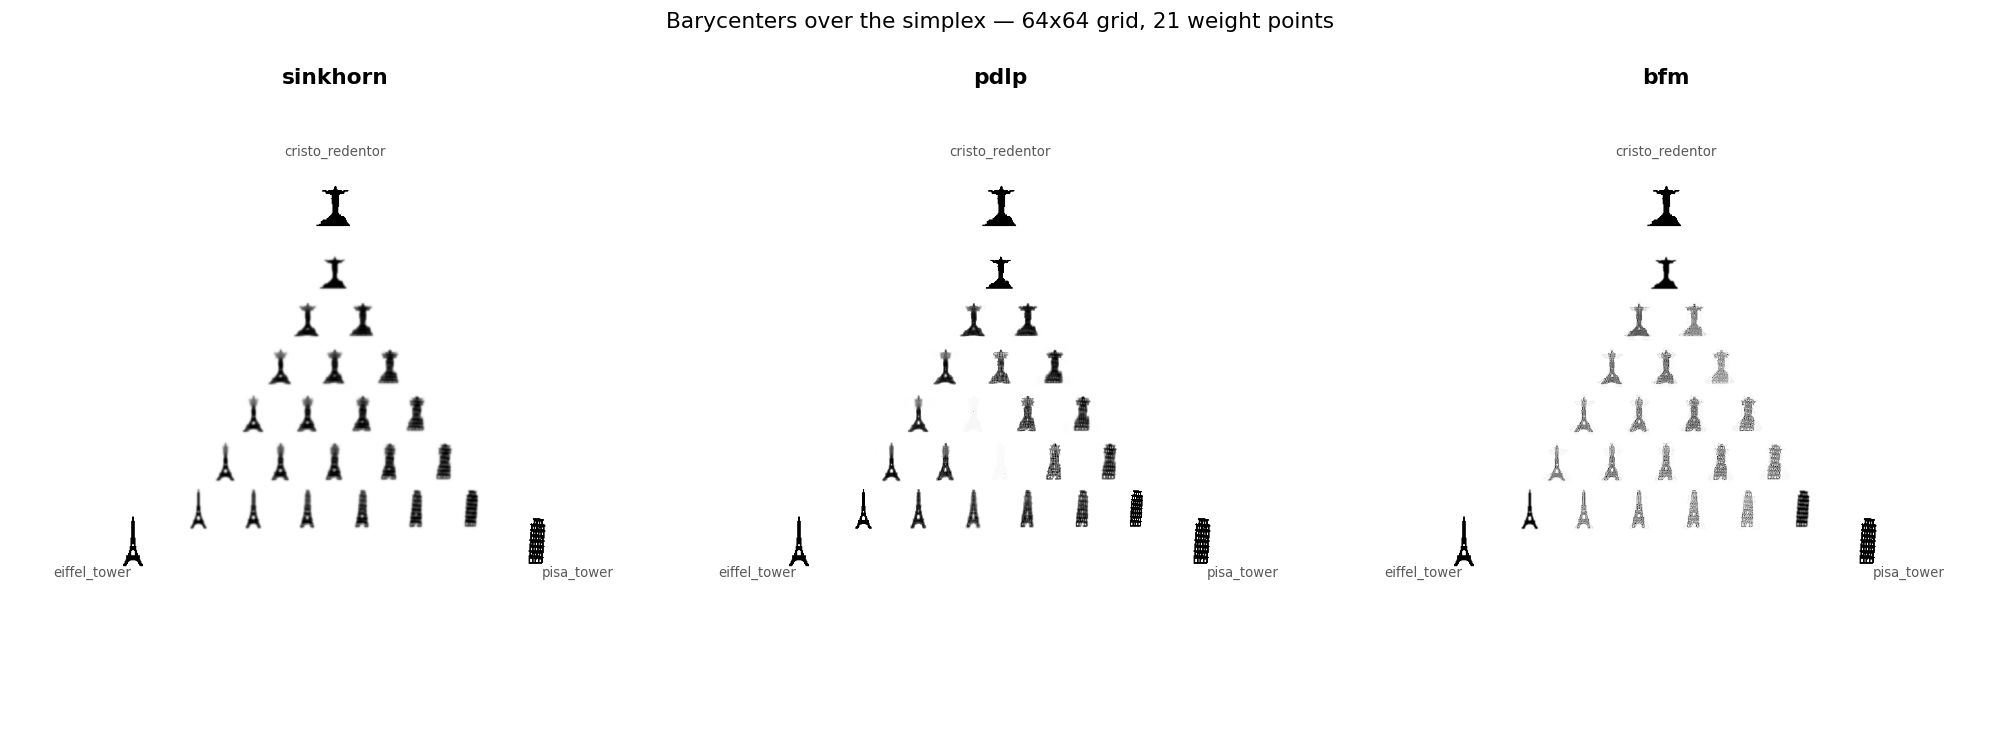

In [8]:
num_measures = len(measures)
angles = np.pi / 2 + 2.0 * np.pi * np.arange(num_measures) / num_measures
circle_pts = np.stack([np.cos(angles), np.sin(angles)], axis=1)

fig, axes_fig = plt.subplots(1, len(SOLVERS), figsize=(5.6 * len(SOLVERS), 5.9))

for ax, (name, bary_list) in zip(np.atleast_1d(axes_fig), fields.items()):
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_xlim(-2.05, 2.05)
    ax.set_ylim(-1.85, 2.05)

    # Input marginals, pushed outside the simplex and labelled radially outward so
    # the text never lands on the vertex barycenter sitting just inside it.
    for (x, y), field, label in zip(circle_pts, measure_fields, SELECTED):
        px, py = 1.48 * x, 1.42 * y
        ab = AnnotationBbox(OffsetImage(field, cmap='Greys', zoom=0.5),
                            (px, py), frameon=False)
        ax.add_artist(ab)
        ax.text(px + 0.30 * x, py + 0.30 * y, label.rsplit('.', 1)[0],
                ha='center', va='bottom' if y >= 0 else 'top',
                fontsize=8, color='0.35')

    for lmb, field in zip(lambda_grid, bary_list):
        pos = (lmb[:, None] * circle_pts).sum(axis=0)
        ab = AnnotationBbox(OffsetImage(field, cmap='Greys', zoom=0.4),
                            pos, frameon=False)
        ax.add_artist(ab)

    ax.set_title(name, fontsize=13, fontweight='bold', pad=14)

fig.suptitle(f'Barycenters over the simplex — {grid_shape[0]}x{grid_shape[1]} grid, '
             f'{len(lambda_grid)} weight points', y=1.04, fontsize=13)
fig.tight_layout()
fig.savefig('../figures/barycenter_solver_sweep.png', bbox_inches='tight')
fig.savefig('../figures/barycenter_solver_sweep.pdf', bbox_inches='tight')
plt.show()


## Runtime

             mean   median     min      max  first_call
solver                                                 
bfm       184.763  118.768  11.549  535.216     419.479
pdlp      103.126   93.397  23.411  155.998      84.345
sinkhorn    1.061    0.934   0.341    2.391       5.959

Fraction of solves that exhausted the iteration budget:
solver
bfm         0.000
pdlp        0.571
sinkhorn    0.000


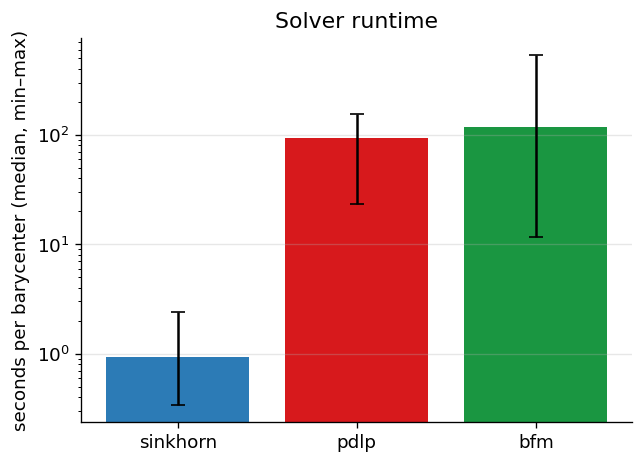

In [9]:
# Drop λ index 0 per solver: that call carries JAX compilation.
steady = df[df['lambda_index'] > 0]
runtime = (steady.groupby('solver')['runtime']
           .agg(['mean', 'median', 'min', 'max'])
           .join(df[df['lambda_index'] == 0].set_index('solver')['runtime'].rename('first_call'))
           .round(3))
print(runtime.to_string())

hit_cap = (df.assign(at_cap=df['iterations'] >= PDLP_PARAMS['maxiter'])
           .groupby('solver')['at_cap'].mean().dropna())
print('\nFraction of solves that exhausted the iteration budget:')
print(hit_cap.round(3).to_string())

fig, ax = plt.subplots(figsize=(5.5, 4))
order = runtime['median'].sort_values().index
ax.bar(order, runtime.loc[order, 'median'],
       yerr=[runtime.loc[order, 'median'] - runtime.loc[order, 'min'],
             runtime.loc[order, 'max'] - runtime.loc[order, 'median']],
       color=['#2C7BB6', '#D7191C', '#1A9641'], capsize=4)
ax.set_yscale('log')
ax.set_ylabel('seconds per barycenter (median, min–max)')
ax.set_title('Solver runtime')
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig('../figures/barycenter_solver_runtime.png', bbox_inches='tight')
plt.show()

## Agreement

Two checks, both in total-variation distance ½‖p − q‖₁ between normalised fields:

- **vertex error** — at a simplex corner the barycenter must reproduce that marginal
  exactly, so this measures each solver against ground truth;
- **pairwise distance** — how far the solvers drift from each other across all λ.

In [10]:
def tv(p, q):
    return 0.5 * float(np.abs(np.asarray(p) - np.asarray(q)).sum())


vertex_rows = []
for idx, lmb in enumerate(lambda_grid):
    corner = np.argmax(lmb)
    if lmb[corner] < 1.0 - 1e-9:      # not a vertex of the simplex
        continue
    for name in SOLVERS:
        vertex_rows.append(dict(solver=name, vertex=SELECTED[corner],
                                tv_error=tv(fields[name][idx], measure_fields[corner])))

vertex = pd.DataFrame(vertex_rows).pivot(index='vertex', columns='solver', values='tv_error')
print('TV distance to the marginal at each simplex vertex (0 = exact):')
print(vertex.round(4).to_string())

names = list(SOLVERS)
pair_rows = []
for i, a in enumerate(names):
    for b in names[i + 1:]:
        dists = [tv(fields[a][k], fields[b][k]) for k in range(len(lambda_grid))]
        pair_rows.append(dict(pair=f'{a} vs {b}', mean_tv=np.mean(dists), max_tv=np.max(dists)))

print('\nPairwise TV distance across all lambdas:')
print(pd.DataFrame(pair_rows).round(4).to_string(index=False))

TV distance to the marginal at each simplex vertex (0 = exact):
solver                  bfm    pdlp  sinkhorn
vertex                                       
cristo_redentor.jpg  0.1048  0.0005    0.1451
eiffel_tower.jpg     0.1740  0.0006    0.2409
pisa_tower.jpg       0.1629  0.0002    0.1966

Pairwise TV distance across all lambdas:
            pair  mean_tv  max_tv
sinkhorn vs pdlp   0.1141  0.2409
 sinkhorn vs bfm   0.1675  0.2192
     pdlp vs bfm   0.1722  0.2104


In [11]:
conv = df.groupby('solver')[['iterations', 'error']].agg(['mean', 'max']).round(6)
print('Solver-reported convergence (BFM reports neither):')
print(conv.to_string())

if 'neg_mass' in df:
    neg = df.groupby('solver')['neg_mass'].agg(['mean', 'max']).dropna().round(8)
    print('\nNegative mass clipped from the PDLP iterate (of total mass 1.0):')
    print(neg.to_string())


Solver-reported convergence (BFM reports neither):
           iterations             error          
                 mean     max      mean       max
solver                                           
bfm               NaN     NaN       NaN       NaN
pdlp      3205.095238  4095.0  0.000302  0.000802
sinkhorn    67.666667   141.0  0.000089  0.000100

Negative mass clipped from the PDLP iterate (of total mass 1.0):
            mean       max
solver                    
pdlp    0.000011  0.000108


## Reading the results

The vertex check is the one with a ground truth: at λ = e_i the barycenter must be
marginal i exactly.  PDLP lands there (TV ≈ 5e-4) because it solves the unregularised
LP; Sinkhorn and BFM do not, and their vertex error is the size of the blur each
method introduces — entropic smoothing at `reg=1e-3` for Sinkhorn, grid diffusion in
the pushforward for BFM.  That same blur is why the three solvers sit ~0.11–0.17 TV
apart across the simplex: they are not disagreeing about the barycenter so much as
carrying different amounts of smoothing.

Cost separates them far harder than accuracy does.  The ranking is stable and wide:
Sinkhorn is sub-second, PDLP tens of seconds, BFM one to two minutes per barycenter —
two to three orders of magnitude between the fastest and the slowest on an identical
problem.  Read the absolute numbers from the runtime table above rather than from here,
and treat them as upper bounds: this box has four GPUs shared between users, and a
sweep run alongside other jobs inflates every statistic, medians included -- across
reruns the Sinkhorn median moved between 0.19 s and 0.93 s purely from contention,
while every accuracy number below stayed bit-identical.  BFM's position is not a property of the method but of its
c-transform on a coarse grid; see `bfm_subroutine_timings.ipynb`.

**Caveat on PDLP:** at these settings it does not reach `tol`.  57% of the solves exhaust the
iteration budget and stop at a primal residual around 3e-4, and one λ in the panel above
is visibly washed out as a result.  Its vertex accuracy is real, but its runtime is a
floor, not a converged cost — raise `maxiter` before quoting it as a converged number.

**Device choice.** All three solvers run on the same device here, which is what makes
the runtimes comparable — but the ranking is not device-independent. Measured on one
λ, per barycenter: Sinkhorn 0.19 s (GPU) vs 6.0 s (CPU), PDLP 33 s vs 502 s, BFM 120 s
vs 31 s. The two dense-linear-algebra solvers want the GPU by an order of magnitude,
while BFM is ~4x faster on CPU because its c-transform is a sequential scan. On GPU the
whole sweep is ~54 min; on CPU ~3 h.
